# Last-Layer Variational Inference for 2D Heat Failure Classification

This notebook keeps a small convolutional feature extractor deterministic and places a variational posterior only on the final linear head. That is the scalable VI path for larger backbones in Deep-UQ.

The scientific task is binary classification:

- class 0: safe thermal regime
- class 1: failure regime where the maximum temperature exceeds a threshold


In [1]:
import sys
from pathlib import Path

repo_root = Path.cwd().resolve().parents[1]
src_path = repo_root / "src"
if str(src_path) not in sys.path:
    sys.path.insert(0, str(src_path))


In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, TensorDataset

from deepuq.methods import LastLayerVariationalInference, predict_vi_uq, vi_elbo_step


## Heat-map classification dataset

We generate smooth 2D source fields, diffuse them with repeated average-pooling steps, and label a sample as failure if the resulting maximum temperature exceeds a fixed threshold. OOD samples use sharper and stronger sources.


In [3]:
torch.manual_seed(3)
size = 16

def smooth_field(field, steps=6):
    out = field
    for _ in range(steps):
        out = F.avg_pool2d(out, kernel_size=3, stride=1, padding=1)
    return out

def random_source(ood=False):
    field = torch.randn(1, 1, size, size)
    field = smooth_field(field, steps=4)
    if ood:
        field = 1.6 * field + 0.8 * torch.randn_like(field)
    else:
        field = 0.8 * field
    return field

def build_dataset(n_samples, ood=False):
    xs, ys = [], []
    for _ in range(n_samples):
        source = random_source(ood=ood)
        temp = smooth_field(source, steps=8)
        label = int(temp.max().item() > (0.12 if not ood else 0.18))
        xs.append(source)
        ys.append(label)
    return torch.cat(xs, dim=0), torch.tensor(ys)

x_train, y_train = build_dataset(192)
x_val, y_val = build_dataset(48)
x_test, y_test = build_dataset(48)
x_ood, y_ood = build_dataset(48, ood=True)
train_loader = DataLoader(TensorDataset(x_train, y_train), batch_size=32, shuffle=True)


In [4]:
class HeatFeatureExtractor(nn.Module):
    def __init__(self, feature_dim=32):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 8, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(8, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d(1),
        )
        self.proj = nn.Linear(16, feature_dim)

    def forward(self, x):
        feats = self.features(x).flatten(1)
        return self.proj(feats)

backbone = HeatFeatureExtractor(feature_dim=32)
model = LastLayerVariationalInference(backbone, feature_dim=32, output_dim=2, task="classification", prior_sigma=0.2)
optimizer = torch.optim.Adam(model.parameters(), lr=2e-3)
criterion = nn.CrossEntropyLoss()

history = []
for _ in range(70):
    model.train()
    for xb, yb in train_loader:
        optimizer.zero_grad(set_to_none=True)
        loss, _, _ = vi_elbo_step(
            model,
            xb,
            yb,
            num_batches=len(train_loader),
            criterion=criterion,
            kl_weight=0.01,
        )
        loss.backward()
        optimizer.step()
    history.append(loss.item())


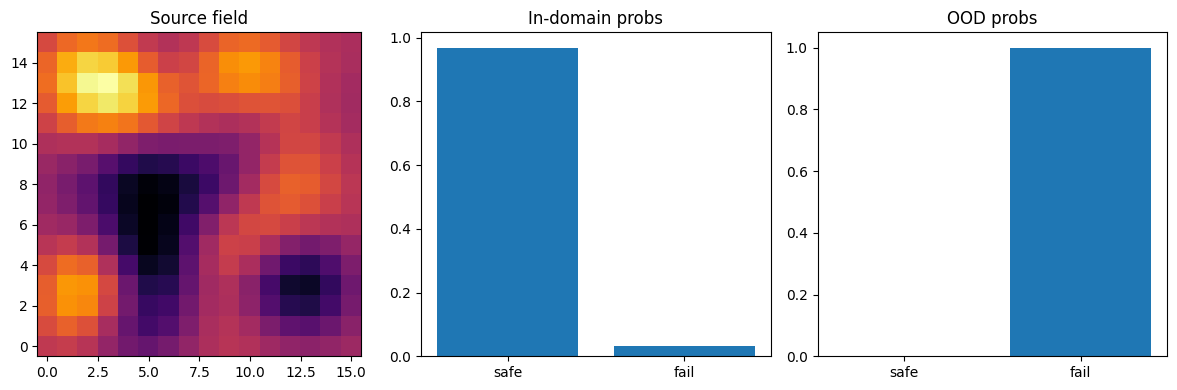

In [5]:
uq_test = predict_vi_uq(model, x_test, n_samples=40)
uq_ood = predict_vi_uq(model, x_ood, n_samples=40)

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].imshow(x_test[0, 0], cmap="inferno", origin="lower")
axes[0].set_title("Source field")
axes[1].bar(["safe", "fail"], uq_test.probs[0].cpu())
axes[1].set_title("In-domain probs")
axes[2].bar(["safe", "fail"], uq_ood.probs[0].cpu())
axes[2].set_title("OOD probs")
plt.tight_layout()
